In [ ]:
# Importing necessary libraries
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import torch
from torchvision import transforms
import torch.nn as nn
from torch.utils.data.dataloader import Dataset, DataLoader

In [3]:
# Setting up device type
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Loading all face image paths
image_paths = []
base_path = "datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
for file in os.listdir(base_path):
    image_paths.append(os.path.join(base_path, file))

print("Num of images:", len(image_paths))

Num of images: 202599


In [5]:
# Transformation to apply on the face images
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

(218, 178, 3)


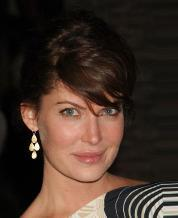

In [6]:
idx = random.randint(0, len(image_paths))
image = Image.open(image_paths[idx])
print(np.array(image).shape)
image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.81960785].


torch.Size([3, 64, 64])


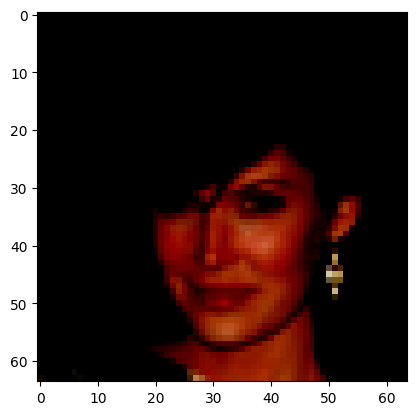

In [7]:
# Visualizing the normalized image
print(transform(image).shape)
plt.imshow(transform(image).permute(1, 2, 0))  # (H, W, C)
plt.show()

In [8]:
# Creating a pytorch dataset
class MyDataSet(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return(self.transform(image))

    def __len__(self):
        return len(self.image_paths)


In [9]:
dataset = MyDataSet(image_paths=image_paths, transform=transform)
dataloader = DataLoader(dataset=dataset, batch_size=128, num_workers=4, shuffle=True, pin_memory=True)

In [10]:
class Discriminator(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=input_channels, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),  # LeakyReLU prevents dead neurons

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(in_features=256*8*8, out_features=1),
        )

    def forward(self, x):
        output = self.model(x)
        return output


In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=latent_dimension, out_features=4*4*1024)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(in_channels=128, out_channels=3, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        linear_output = self.linear_layer(x)
        linear_output = linear_output.reshape(-1, 1024, 4, 4)
        return self.model(linear_output)

In [12]:
z_dim = 100
epochs = 60
lr_G = 2e-4
lr_D = 1e-4  # Discriminator slightly slower helps stability

G = Generator(latent_dimension=z_dim).to(device)
D = Discriminator(input_channels=3).to(device)

In [ ]:
# Initializing weights of the model with normal distribution
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=16384, out_features=1, bias=True)
  )
)

In [14]:
criterion = nn.BCEWithLogitsLoss()

opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, z_dim, device=device)

In [15]:
# Helper functions to save checkpoint and show generator progress
checkpoints_dir = "/kaggle/working/checkpoints"
Path(checkpoints_dir).mkdir(parents=True, exist_ok=True)

def save_checkpoint(epoch):
    torch.save({
        "G": G.state_dict(),
        "D": D.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D": opt_D.state_dict(),
        "epoch": epoch
    }, f"checkpoints/checkpoint_{epoch}.pt")

def show_images(epoch):
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()

    grid = fake[:16]
    grid = (grid + 1) / 2  # [-1,1] → [0,1]

    fig, axes = plt.subplots(4, 4, figsize=(6,6))
    idx = 0
    for i in range(4):
        for j in range(4):
            axes[i,j].imshow(np.transpose(grid[idx], (1,2,0)))
            axes[i,j].axis("off")
            idx += 1
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

Epoch 0 | D Loss: 0.6737 | G Loss: 0.8798


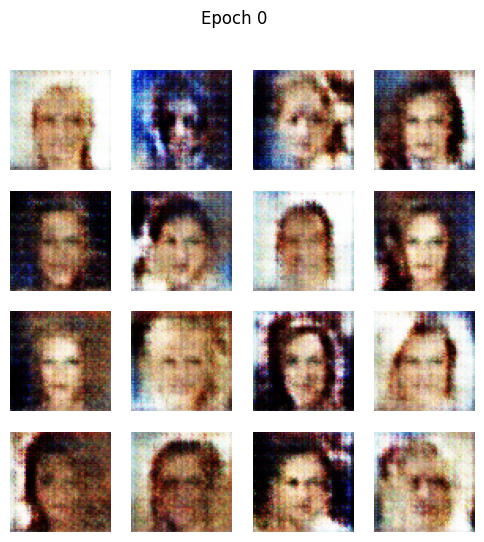

Epoch 1 | D Loss: 0.6864 | G Loss: 0.9027
Epoch 2 | D Loss: 0.6689 | G Loss: 0.9659
Epoch 3 | D Loss: 0.6983 | G Loss: 0.8590


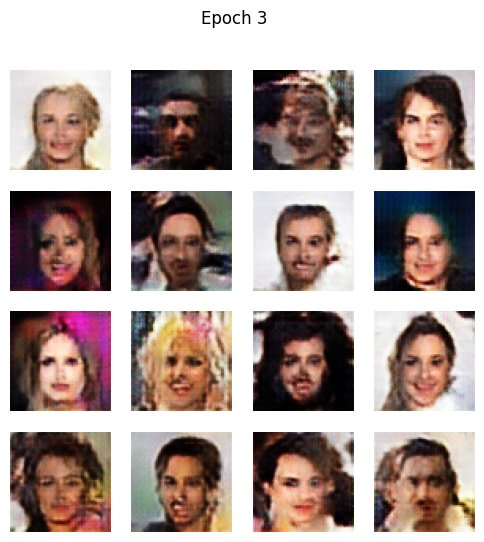

Epoch 4 | D Loss: 0.6701 | G Loss: 1.0370
Epoch 5 | D Loss: 0.6726 | G Loss: 0.8668
Epoch 6 | D Loss: 0.6715 | G Loss: 0.9219


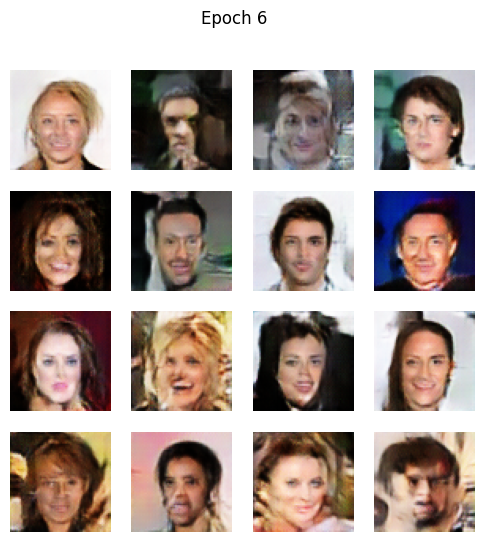

Epoch 7 | D Loss: 0.6848 | G Loss: 0.8276
Epoch 8 | D Loss: 0.6906 | G Loss: 0.8745
Epoch 9 | D Loss: 0.6918 | G Loss: 0.7881


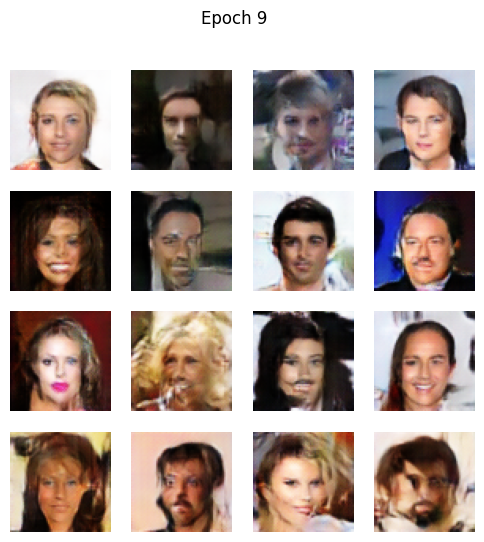

Epoch 10 | D Loss: 0.6744 | G Loss: 0.8698
Epoch 11 | D Loss: 0.7214 | G Loss: 0.8975
Epoch 12 | D Loss: 0.6651 | G Loss: 1.0015


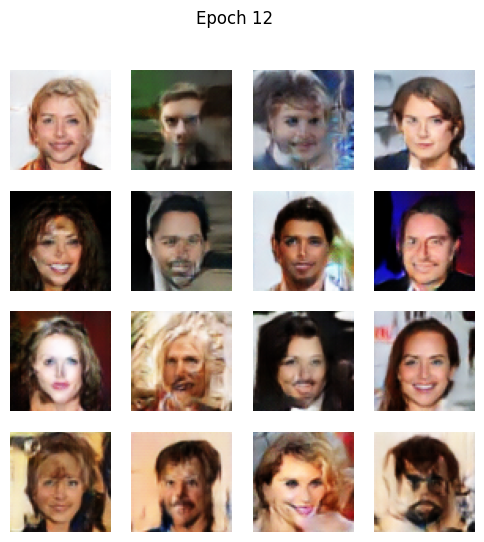

Epoch 13 | D Loss: 0.7309 | G Loss: 1.0972
Epoch 14 | D Loss: 0.6919 | G Loss: 0.7805
Epoch 15 | D Loss: 0.6640 | G Loss: 1.0938


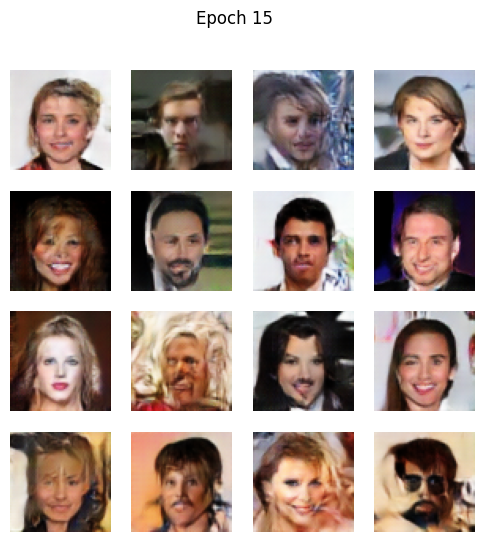

Epoch 16 | D Loss: 0.6333 | G Loss: 0.8614
Epoch 17 | D Loss: 0.6344 | G Loss: 1.0520
Epoch 18 | D Loss: 0.7226 | G Loss: 0.9121


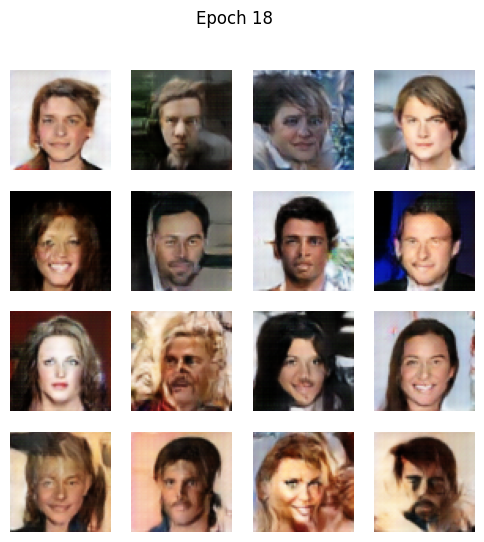

Epoch 19 | D Loss: 0.6116 | G Loss: 0.8801
Epoch 20 | D Loss: 0.6855 | G Loss: 1.0213
Epoch 21 | D Loss: 0.6364 | G Loss: 1.4263


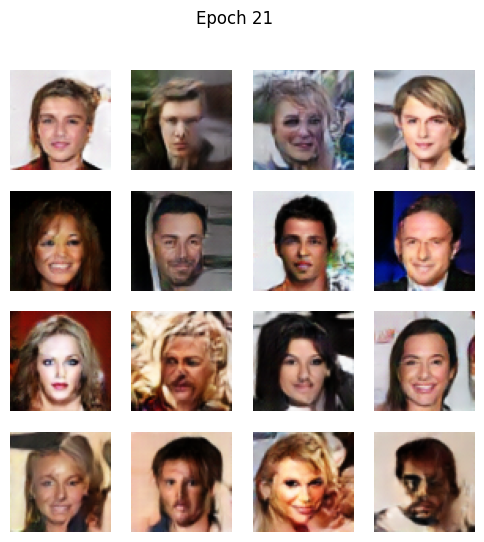

Epoch 22 | D Loss: 0.6191 | G Loss: 1.2882
Epoch 23 | D Loss: 0.6178 | G Loss: 1.0123
Epoch 24 | D Loss: 0.6665 | G Loss: 1.4756


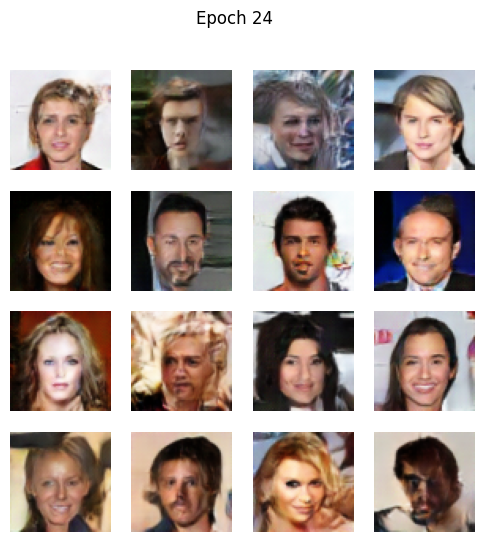

Epoch 25 | D Loss: 0.6164 | G Loss: 1.0679
Epoch 26 | D Loss: 0.6639 | G Loss: 0.9823
Epoch 27 | D Loss: 0.6856 | G Loss: 0.8115


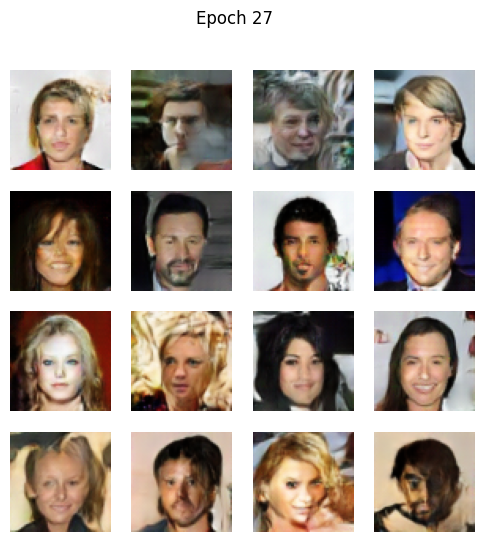

Epoch 28 | D Loss: 0.5790 | G Loss: 1.5012
Epoch 29 | D Loss: 0.6620 | G Loss: 1.5834
Epoch 30 | D Loss: 0.6258 | G Loss: 1.0861


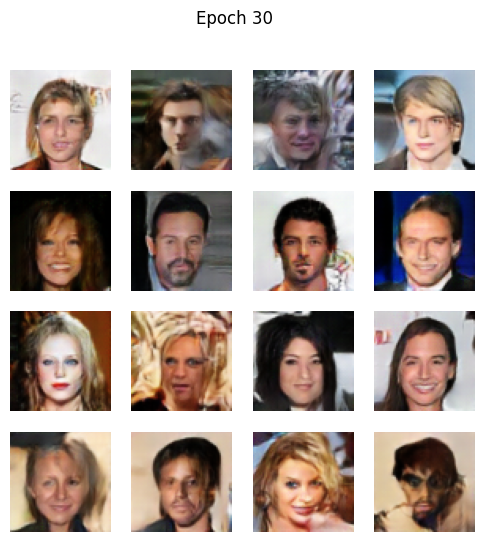

Epoch 31 | D Loss: 0.5852 | G Loss: 1.5185
Epoch 32 | D Loss: 0.5677 | G Loss: 1.3780
Epoch 33 | D Loss: 0.5716 | G Loss: 1.7032


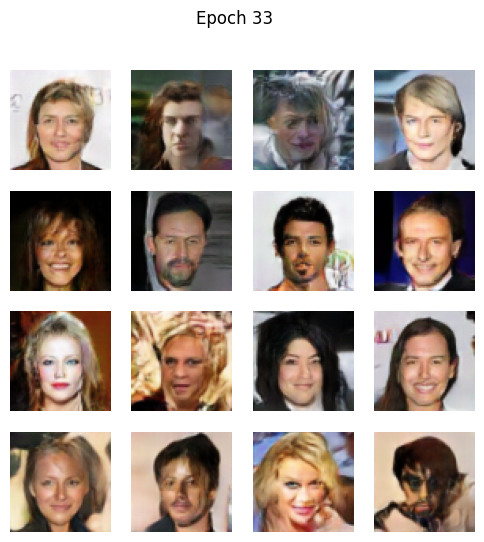

Epoch 34 | D Loss: 0.6581 | G Loss: 1.3114
Epoch 35 | D Loss: 0.6351 | G Loss: 1.0612
Epoch 36 | D Loss: 0.6202 | G Loss: 1.3199


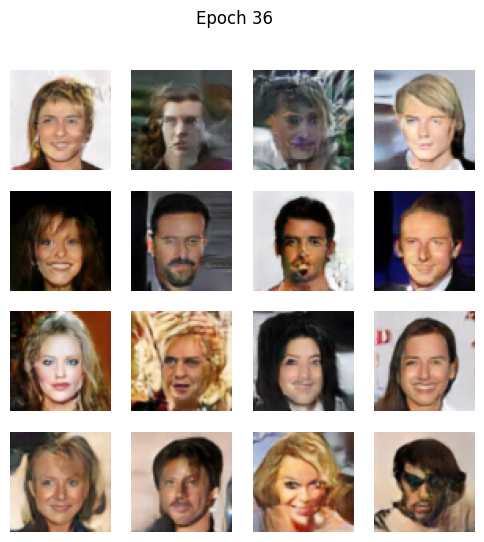

Epoch 37 | D Loss: 0.5617 | G Loss: 1.1567
Epoch 38 | D Loss: 0.5759 | G Loss: 0.9857
Epoch 39 | D Loss: 0.6816 | G Loss: 2.2853


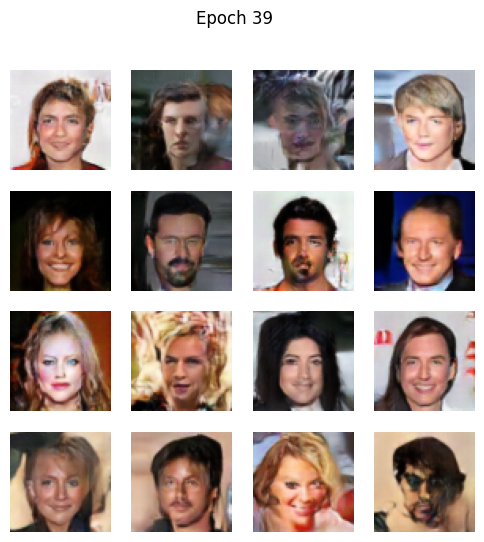

Epoch 40 | D Loss: 0.5236 | G Loss: 1.9030
Epoch 41 | D Loss: 0.6112 | G Loss: 1.0774
Epoch 42 | D Loss: 0.5510 | G Loss: 1.4540


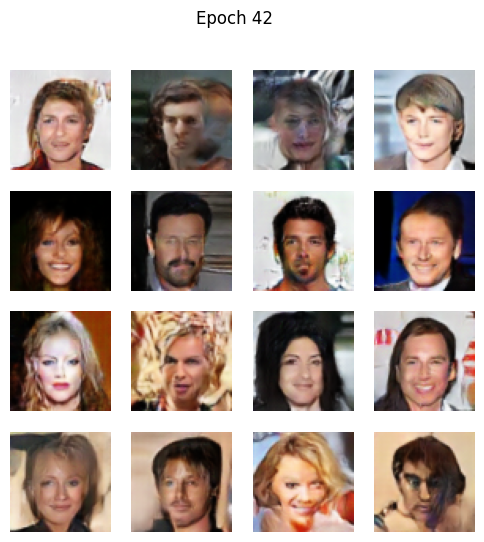

Epoch 43 | D Loss: 0.6137 | G Loss: 1.1428
Epoch 44 | D Loss: 0.5965 | G Loss: 1.5634
Epoch 45 | D Loss: 0.5012 | G Loss: 1.3055


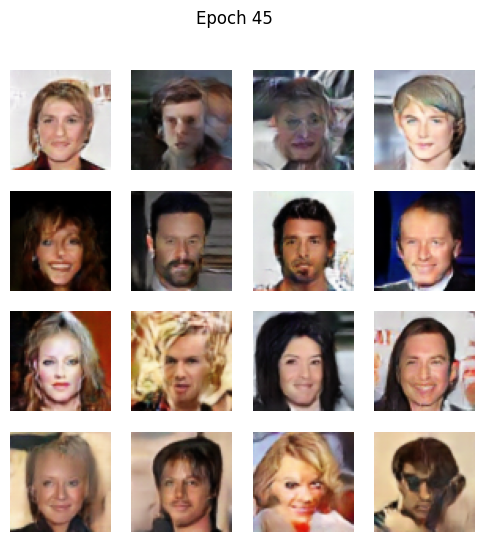

Epoch 46 | D Loss: 0.5092 | G Loss: 1.1934
Epoch 47 | D Loss: 0.5579 | G Loss: 0.9780
Epoch 48 | D Loss: 0.5778 | G Loss: 0.7980


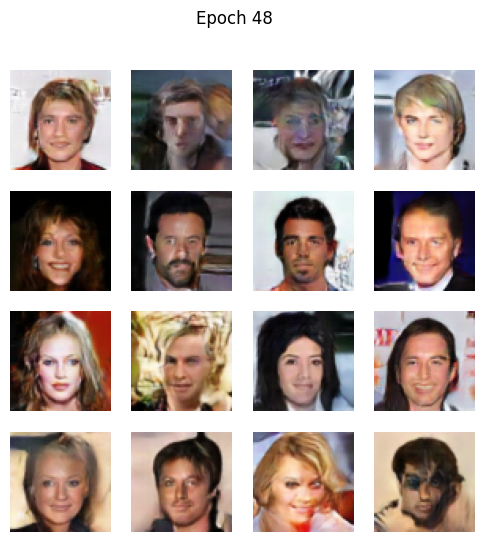

Epoch 49 | D Loss: 0.4775 | G Loss: 1.4095
Epoch 50 | D Loss: 0.5404 | G Loss: 1.3449
Epoch 51 | D Loss: 0.5084 | G Loss: 3.1717


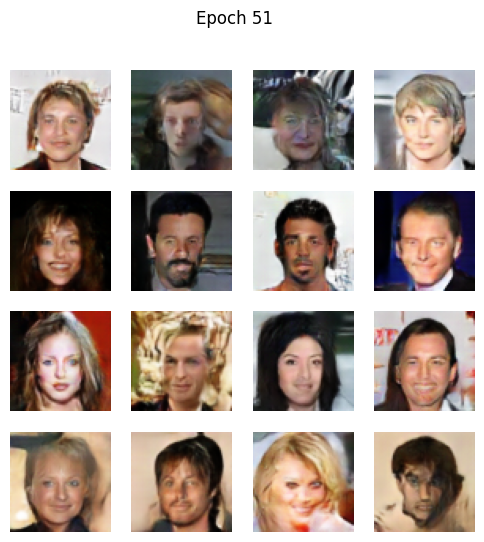

Epoch 52 | D Loss: 0.6363 | G Loss: 2.8734
Epoch 53 | D Loss: 0.6124 | G Loss: 2.2432
Epoch 54 | D Loss: 0.4373 | G Loss: 1.6725


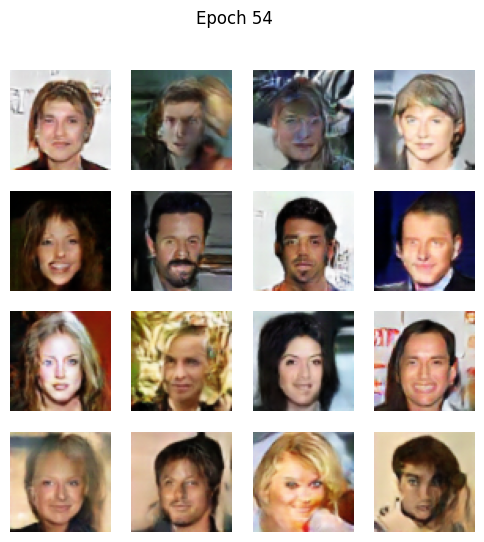

Epoch 55 | D Loss: 0.4065 | G Loss: 2.9706
Epoch 56 | D Loss: 0.4616 | G Loss: 2.4687
Epoch 57 | D Loss: 0.3614 | G Loss: 2.2851


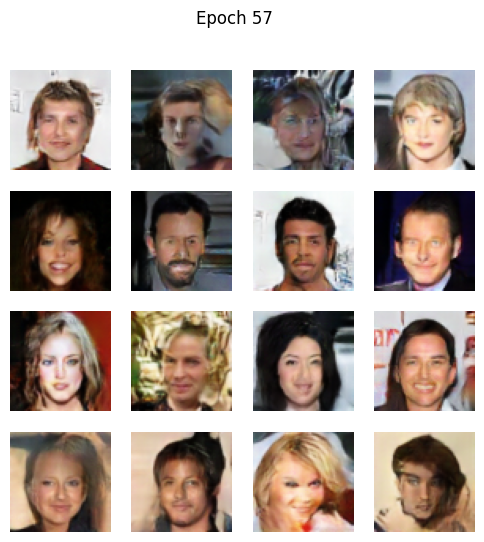

Epoch 58 | D Loss: 0.4941 | G Loss: 2.3901
Epoch 59 | D Loss: 0.6713 | G Loss: 0.8170


In [ ]:
# Training loop
for epoch in range(epochs):
    for real in dataloader:     
        real = real.to(device)
        batch_size = real.size(0)

        # =======================
        # Train Discriminator
        # =======================
        noise = torch.randn(batch_size, z_dim, device=device)
        fake = G(noise)

        D_real = D(real).view(-1)
        D_fake = D(fake.detach()).view(-1)

        loss_D_real = criterion(D_real, torch.full_like(D_real, 0.9))   # real label = 0.9
        loss_D_fake = criterion(D_fake, torch.zeros_like(D_fake))

        loss_D = (loss_D_real + loss_D_fake) / 2

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # =======================
        # Train Generator
        # =======================
        output = D(fake).view(-1)
        loss_G = criterion(output, torch.ones_like(output))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    if epoch % 3 == 0:
        save_checkpoint(epoch)
        show_images(epoch)

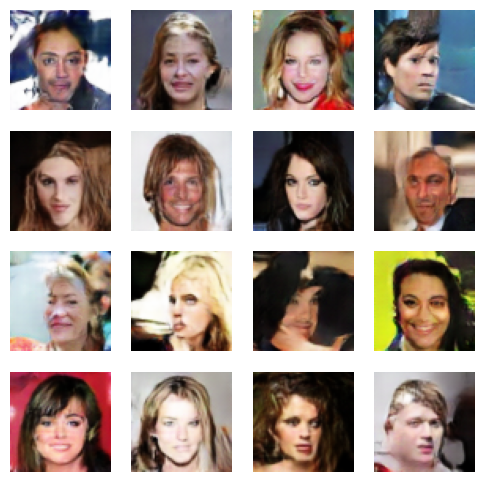

In [22]:
# Generating new images from the trained generator
noise = torch.randn(16, z_dim, device=device)

with torch.no_grad():
    fake = G(noise).detach().cpu()

grid = fake[:16]
grid = (grid + 1) / 2  # [-1,1] → [0,1]

fig, axes = plt.subplots(4, 4, figsize=(6,6))
idx = 0
for i in range(4):
    for j in range(4):
        axes[i,j].imshow(np.transpose(grid[idx], (1,2,0)))
        axes[i,j].axis("off")
        idx += 1
plt.show()